<a href="https://colab.research.google.com/github/Jokiba/ml-predicted-category-product-final-project/blob/main/notebooks/product_category_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product category prepare and clean dataset

In this workbook, which is part of the final project, we will do:


*   Clearing missing values ​​per row

*   Standardization of values ​​(titles, fields) by columns
*   Converting columns to the appropriate data types


*   Analyze the columns to see if they are needed by the model

*   Deleting unnecessary columns
*   Creating new columns - features engineering





## Loading data
Loading dataset into code from GitHub public repository.

In [71]:
import pandas as pd

# load dataset from GitHub
url = "https://raw.githubusercontent.com/Jokiba/ml-predicted-category-product-final-project/main/data/products.csv"
df = pd.read_csv(url)

## Clearing rows of specific columns
In this step, we will read the rows of important columns for the model.<br>Columns with the name of the product and its category, if they have missing values, their rows will be cleared.<br>After that, we check the columns and their missing values.

In [72]:
# Drop rows of specific columns with missing values
df_clean = df.dropna(subset=["Product Title", " Category Label"])

# Display shape of the new dataset
print("New dataset shape:", df_clean.shape)

# Count missing values per column
print("Missing values per column:")
print(df_clean.isna().sum())

New dataset shape: (35096, 8)
Missing values per column:
product ID           0
Product Title        0
Merchant ID          0
 Category Label      0
_Product Code       94
Number_of_Views     14
Merchant Rating    170
 Listing Date       58
dtype: int64


## Deleting columns in the dataset
We delete unnecessary columns in the dataset.<br>These are columns that cannot contribute to the prediction model.

In [73]:
# Removing unnecessary columns in the dataset
df_clean = df_clean.drop(columns=["product ID", "Merchant ID", "_Product Code", " Listing Date  "])

# Check dataset changes
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35096 entries, 0 to 35310
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Title    35096 non-null  object 
 1    Category Label  35096 non-null  object 
 2   Number_of_Views  35082 non-null  float64
 3   Merchant Rating  34926 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.3+ MB


## Standardization of column names
In this step, we standardize the column names.<br>We convert the names to lowercase letters, clean up spaces, and separate words with an underscore.

In [74]:
# Standardization of column names
df_clean.columns = (df_clean.columns.str.lower().str.strip().str.replace(" ", "_"))

# Check changes
df_clean.columns.tolist()

['product_title', 'category_label', 'number_of_views', 'merchant_rating']

## Standardization of the value of the target variable

In this step, we standardize the values ​​of the column - "category_label".<br>We convert all values ​​to lowercase letters.<br>We combine the same values ​​that are written differently into one product category.

In [75]:
# Standardize column values ​​- 'category_label'
df_clean['category_label'] = df_clean['category_label'].str.lower().str.strip()

# Mapping values ​​of different name
mapping = {
    'mobile phone': 'phone',
    'mobile phones': 'phone',
    'digital cameras': 'camera',
    'cpus': 'cpu',
    'fridges': 'fridge',
    'tvs': 'tv'
}
df_clean['category_label'] = df_clean['category_label'].replace(mapping)

# Check changes
df_clean['category_label'].value_counts()

,count
category_label,
fridge freezers,5470
phone,4057
washing machines,4015
cpu,3831
fridge,3559
tv,3541
dishwashers,3405
camera,2689
microwaves,2328


## Is the 'number_of_views' column required by the model
In this step we will check if the 'number_of_views' column is useful for predicting the product category.

Number of views summary by product category:

                   count         mean          std  min      25%     50%  \
category_label                                                             
camera            2687.0  2460.035355  1435.849647  4.0  1228.00  2422.0   
cpu               3830.0  2499.996084  1453.433566  2.0  1230.25  2497.0   
dishwashers       3403.0  2481.573612  1455.742853  0.0  1223.00  2457.0   
freezers          2201.0  2505.178555  1424.786517  0.0  1306.00  2497.0   
fridge            3557.0  2498.428451  1432.485091  0.0  1272.00  2481.0   
fridge freezers   5467.0  2536.048107  1441.285799  0.0  1280.50  2578.0   
microwaves        2328.0  2477.255155  1427.931549  0.0  1249.50  2452.0   
phone             4055.0  2530.606658  1424.851076  1.0  1307.00  2553.0   
tv                3541.0  2507.304716  1446.123626  1.0  1211.00  2548.0   
washing machines  4013.0  2485.595066  1433.040816  0.0  1264.00  2501.0   

                      75%     max  
categ

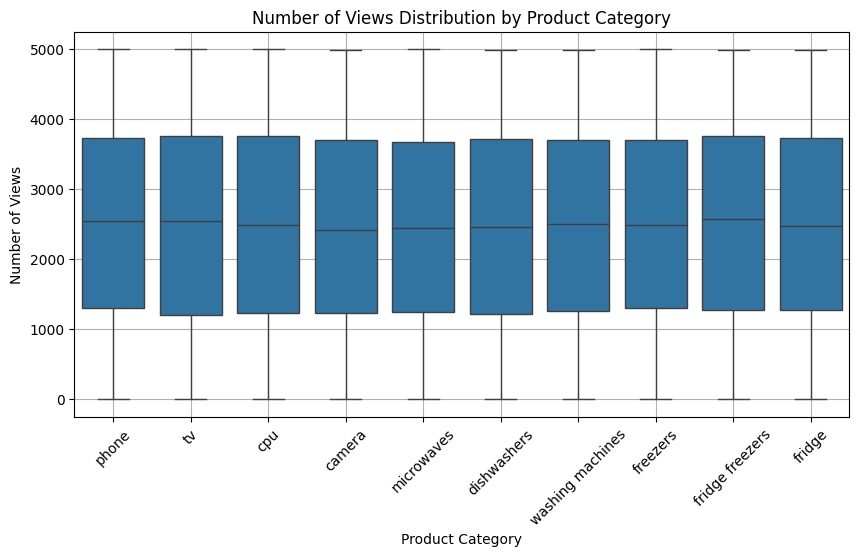

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Show summary statistics grouped by category_label
print("Number of views summary by product category:\n")
print(df_clean.groupby('category_label', observed=False)['number_of_views'].describe())

# Boxplot of views by category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='category_label', y='number_of_views')
plt.xticks(rotation= 45)
plt.title("Number of Views Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Views")
plt.grid(True)
plt.show()


## Box plot analysis
In the diagram, we see that the product categories have a similar distribution of the number of views per product.<br>Based on this, we conclude that the column 'number_of_views' has no significance for predicting the product category.

## Is the 'merchant_rating' column required for the model
In this step we will check if the 'merchant_rating' column is useful for predicting the product category.

Merchant rating summary by product category:
                   count      mean       std  min  25%  50%  75%  max
category_label                                                       
camera            2677.0  2.985394  1.173805  1.0  2.0  3.0  4.0  5.0
cpu               3813.0  2.982533  1.137671  1.0  2.0  3.0  4.0  5.0
dishwashers       3393.0  3.049543  1.148286  1.0  2.1  3.1  4.0  5.0
freezers          2191.0  2.983980  1.136370  1.0  2.0  3.0  3.9  5.0
fridge            3543.0  3.001298  1.142661  1.0  2.0  3.0  3.9  5.0
fridge freezers   5442.0  2.974881  1.151986  1.0  2.0  3.0  4.0  5.0
microwaves        2317.0  2.998576  1.160673  1.0  2.0  3.0  4.0  5.0
phone             4044.0  2.991172  1.161793  1.0  2.0  3.0  4.0  5.0
tv                3520.0  2.973523  1.150308  1.0  2.0  2.9  4.0  5.0
washing machines  3986.0  3.046136  1.158258  1.0  2.1  3.1  4.1  5.0


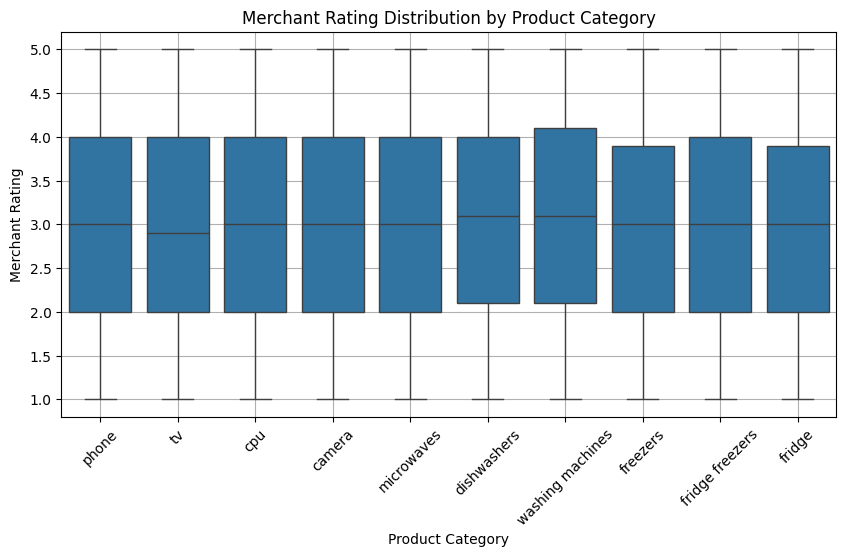

In [77]:
# Show summary statistics grouped by category_label
print("Merchant rating summary by product category:")
print(df_clean.groupby('category_label', observed=False)['merchant_rating'].describe())

# Boxplot of views by category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='category_label', y='merchant_rating')
plt.xticks(rotation= 45)
plt.title("Merchant Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Merchant Rating")
plt.grid(True)
plt.show()


## Box plot analysis
In the diagram, we see that the product categories have a similar distribution of merchant ratings per product.<br>Based on this, we conclude that the 'merchant_rating' column has no significance for predicting the product category.

## Creating a new product name length column
In this step, we will create a new product name length feature (column) based on the existing product name column.<br>Our goal is to check if there is an association (pattern) between the name length and the product category.<br>This association (if any) will help us when predicting the product category.


In [78]:
# Create new column with length of each product_title
df_clean['title_length'] = df_clean['product_title'].astype(str).str.len()

# Show basic stats
print("Title length summary:")
df_clean['title_length'].describe()

Title length summary:


,title_length
count,35096.000000
mean,52.984813
std,22.438958
min,5.000000
25%,39.000000
50%,52.000000
75%,65.000000
max,200.000000


## Is the new 'title_length' column useful for the model
In this step we will check if the 'title_length' column is useful for predicting the product category.

Title length statistics by sentiment:
                   count       mean        std   min   25%   50%   75%    max
category_label                                                               
camera            2689.0  50.115284  24.548060   6.0  34.0  44.0  61.0  180.0
cpu               3831.0  67.021404  20.210202  11.0  55.0  65.0  76.0  190.0
dishwashers       3405.0  50.206755  17.989980  10.0  39.0  51.0  61.0  192.0
freezers          2201.0  48.769650  18.209715  10.0  37.0  47.0  60.0  168.0
fridge            3559.0  48.509975  18.365958   8.0  36.0  46.0  62.0  173.0
fridge freezers   5470.0  55.237477  20.468326   9.0  42.0  54.0  68.0  170.0
microwaves        2328.0  51.811856  18.798911  11.0  39.0  52.0  65.0  164.0
phone             4057.0  46.240818  30.759028   5.0  27.0  40.0  57.0  200.0
tv                3541.0  54.719006  23.394549   6.0  40.0  53.0  65.0  195.0
washing machines  4015.0  53.042839  18.853608  10.0  42.0  54.0  65.0  149.0


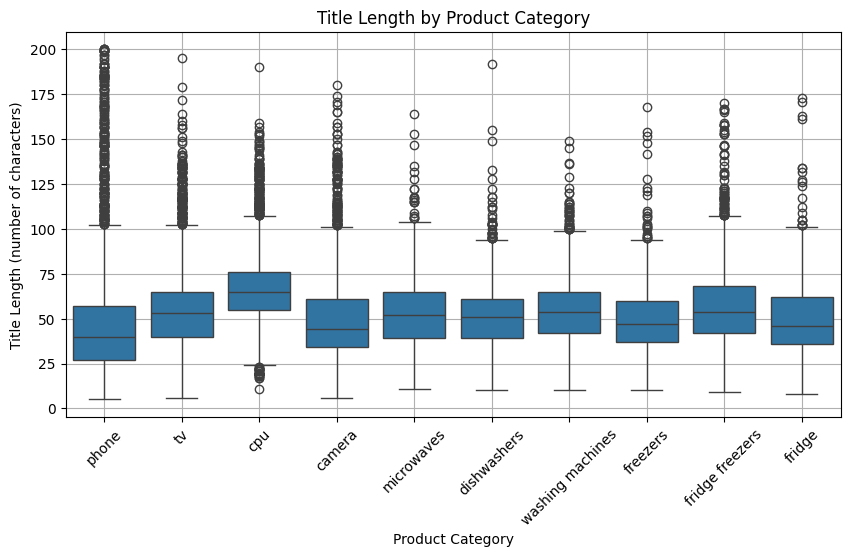

In [79]:
# Group by and describe title length
print("Title length statistics by sentiment:")
print(df_clean.groupby('category_label', observed=False)['title_length'].describe())

# Visualize distribution of review length by sentiment
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='category_label', y='title_length')
plt.xticks(rotation= 45)
plt.title("Title Length by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Title Length (number of characters)")
plt.grid(True)
plt.show()


## Box plot analysis
In the diagram, we can see small differences in product categories that are still not large enough to be useful for product category prediction.

## Creating a new column - feature engineering
We create a new column 'category_in_title' which, based on the existing column 'product_title', finds the keyword for the category.

In [80]:
# Mapping product categories
categories = [
    'fridge freezer',
    'washing machine',
    'dishwasher',
    'microwave',
    'freezer',
    'camera',
    'fridge',
    'phone',
    'tv',
    'cpu'
]
# Pattern for writing categories in a new column as values
pattern = '|'.join(categories)

# Creating a new column
df_clean['category_in_title'] = (
    df_clean['product_title']
    .str.lower()
    .str.extract(f'({pattern})', expand=False)
)


# Checking the results
print(df_clean[['product_title', 'category_label', 'category_in_title']].head(20), "\n")

print(df_clean[['product_title', 'category_label', 'category_in_title']].tail(20), "\n")



                                        product_title category_label  \
0                     apple iphone 8 plus 64gb silver          phone   
1                 apple iphone 8 plus 64 gb spacegrau          phone   
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...          phone   
3                 apple iphone 8 plus 64gb space grey          phone   
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...          phone   
5   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...          phone   
6                apple iphone 8 plus 64 gb space grey          phone   
7                 apple iphone 8 plus 64gb space grey          phone   
8                 apple iphone 8 plus 64gb space grey          phone   
9                 apple iphone 8 plus 64gb space grey          phone   
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver          phone   
11    sim free iphone 8 plus 64gb by apple space grey          phone   
12           apple iphone 8 plus 64gb gold smartphone          p

## Deleting unnecessary columns and converting columns to the appropriate type
We delete the unnecessary columns that we analyzed in the previous steps.<br>We convert the columns representing the categories into the category data type.

In [81]:
# Deleting unnecessary columns
df_clean = df_clean.drop(columns= ['number_of_views', 'merchant_rating', 'title_length'])

# Converting columns to the appropriate type
df_clean[['category_label', 'category_in_title']] = df_clean[['category_label', 'category_in_title']].astype('category')

# Checking changes to the dataset
print(df_clean.columns.tolist(), "\n")
print(df_clean.info(), "\n")
print(df_clean.isna().sum(), "\n")

['product_title', 'category_label', 'category_in_title'] 

<class 'pandas.core.frame.DataFrame'>
Index: 35096 entries, 0 to 35310
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   product_title      35096 non-null  object  
 1   category_label     35096 non-null  category
 2   category_in_title  21641 non-null  category
dtypes: category(2), object(1)
memory usage: 617.7+ KB
None 

product_title            0
category_label           0
category_in_title    13455
dtype: int64 

